# MLT-03 ANN Concepts

- Authored by: *Jay Parmar*
- Last modified on: *27th August 2023*

## In this notebook, we will go through following topics:

- Feature Engineering
- Neural Network Creation
- Strategy Backtesting

The focus of this lab would be to understand the implementation of neural networks using the scikit-learn library. To do so, we will start with importing necessary libraries.

## Part 1 - Training a neural network

In [0]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Apply the default seaborn theme, scaling, and color palette
sns.set()
# One can use different colour palettes
# palettes = ["deep", "muted", "pastel", "bright", "dark", "colorblind"]
# sns.set(palette="deep")

# import warnings
# warnings.filterwarnings('ignore')

%matplotlib inline

In [1]:
# Loading the data from the local file
df = pd.read_csv('MLT03_data_EURUSD_data.csv', index_col=0, parse_dates=True)

In [2]:
# Copying the original dataframe. Will work on the new dataframe.
data = df.copy()
# Checking the shape
print('Number of observations:', data.shape[0])
print('Number of variables:', data.shape[1])

Number of observations: 2343
Number of variables: 6


In [3]:
data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2009-12-31,1.434206,1.443897,1.431045,1.432706,1.432706,0
2010-01-01,1.432706,1.440196,1.432706,1.438994,1.438994,0
2010-01-04,1.431004,1.445191,1.426208,1.442398,1.442398,0
2010-01-05,1.442710,1.448310,1.435194,1.436596,1.436596,0
2010-01-06,1.436596,1.443460,1.429123,1.440403,1.440403,0


### Feature Engineering

In [4]:
# Creating features
features_list = []

# SD based features
for i in range(5, 20, 5):
    col_name = 'std_' + str(i)
    data[col_name] = data['Close'].rolling(window=i).std()
    features_list.append(col_name)
    
# MA based features
for i in range(10, 30, 5):
    col_name = 'ma_' + str(i)
    data[col_name] = data['Close'].rolling(window=i).mean()
    features_list.append(col_name)
    
# Daily pct change based features
for i in range(3, 12, 3):
    col_name = 'pct_' + str(i)
    data[col_name] = data['Close'].pct_change().rolling(i).sum()
    features_list.append(col_name)
    
# Intraday movement
col_name = 'co'
data[col_name] = data['Close'] - data['Open']
features_list.append(col_name)

In [5]:
features_list

['std_5',
 'std_10',
 'std_15',
 'ma_10',
 'ma_15',
 'ma_20',
 'ma_25',
 'pct_3',
 'pct_6',
 'pct_9',
 'co']

In addition, We'll use popular technical indicators to build features. They are as follows:

- [Bollinger Bands](https://en.wikipedia.org/wiki/Bollinger_Bands)
- [Moving Average Convergence/Divergence (MACD)](https://en.wikipedia.org/wiki/MACD)
- [Parabolic Stop And Reverse (SAR)](https://en.wikipedia.org/wiki/Parabolic_SAR)


The discussion about what these technical indicators and how they are built, is out of scope of this session. We'll use `TA-LIB` library to build these indicators.

In [6]:
# Use the following command on the terminal window on Anaconda to install ta-lib if it is not installed
# conda install -c conda-forge ta-lib
import talib as ta

In [7]:
data['upper_band'], data['middle_band'], data['lower_band'] = ta.BBANDS(data['Close'].values)
data['macd'], data['macdsignal'], data['macdhist'] = ta.MACD(data['Close'].values)
data['sar'] = ta.SAR(data['High'].values, data['Low'].values)
features_list +=['upper_band','middle_band','lower_band','macd','sar']

ML algorithms don't work with `NaN` values. However, while creating the above features, we would have many `NaN` values we need to drop from our dataset.

In [8]:
features_list

['std_5',
 'std_10',
 'std_15',
 'ma_10',
 'ma_15',
 'ma_20',
 'ma_25',
 'pct_3',
 'pct_6',
 'pct_9',
 'co',
 'upper_band',
 'middle_band',
 'lower_band',
 'macd',
 'sar']

In [9]:
data[features_list].head()

,std_5,std_10,std_15,ma_10,ma_15,ma_20,ma_25,pct_3,pct_6,pct_9,co,upper_band,middle_band,lower_band,macd,sar
Date,,,,,,,,,,,,,,,,
2009-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.001500,NaN,NaN,NaN,NaN,NaN
2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006288,NaN,NaN,NaN,NaN,1.431045
2010-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.011394,NaN,NaN,NaN,NaN,1.445191
2010-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002732,NaN,NaN,-0.006114,NaN,NaN,NaN,NaN,1.426208
2010-01-06,0.003737,NaN,NaN,NaN,NaN,NaN,NaN,0.000993,NaN,NaN,0.003807,1.444904,1.438219,1.431534,NaN,1.426208


There are null values in many columns. Let's drop them.

In [10]:
data.dropna(inplace=True)

In [11]:
data[features_list].head()

,std_5,std_10,std_15,ma_10,ma_15,ma_20,ma_25,pct_3,pct_6,pct_9,co,upper_band,middle_band,lower_band,macd,sar
Date,,,,,,,,,,,,,,,,
2010-02-16,0.007174,0.008744,0.013772,1.372029,1.379814,1.387765,1.398622,0.006298,0.008339,-0.009467,0.016979,1.381636,1.368802,1.355968,-0.020450,1.353308
2010-02-17,0.006823,0.006695,0.012981,1.369088,1.376987,1.385247,1.394954,-0.001914,-0.012626,-0.009872,-0.015846,1.378081,1.365875,1.353669,-0.020266,1.353797
2010-02-18,0.010875,0.009546,0.014006,1.366253,1.373610,1.382070,1.390800,-0.010262,-0.021224,-0.015841,-0.014914,1.380923,1.361469,1.342016,-0.021051,1.378873
2010-02-19,0.010818,0.009634,0.013834,1.365603,1.371931,1.379440,1.387697,-0.010913,-0.004615,-0.002574,0.014452,1.380425,1.361072,1.341720,-0.020201,1.378873
2010-02-22,0.010814,0.009766,0.012841,1.365113,1.369788,1.376718,1.384492,0.000027,-0.001887,-0.012599,-0.002337,1.380469,1.361124,1.341779,-0.019380,1.378196


As OHLC data is high correlated, we won't be using them as features. Instead, we would use only technical indicators and quantitative features for this exercise. Below we define feature matrix `X`, create the target variable and assign it to the target vector `y`.

In [12]:
import numpy as np

In [13]:
X = data[features_list]
data['target'] = np.where(data['Close'].shift(-1) > data['Close'], 1, -1)
y = data['target']

We will use `train_test_split()` function from the `sklearn.model_selection` package to split our dataset. We will use 20% of our dataset as a test dataset.

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [16]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1848, 16), (462, 16), (1848,), (462,))

Before we can train our neural network, we need to make sure that our data is scaled, that is, it ranges between 0 and 1. We will use `StandardScaler` from the `sklearn.preprocessing` package. We need to train the scaler object on training data only and then apply on training and testing set both.

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
#sns.pairplot(X_train_scaled_df[features_list]);

In [20]:
X_train_scaled_df.describe().round(2)

,std_5,std_10,std_15,ma_10,ma_15,ma_20,ma_25,pct_3,pct_6,pct_9,co,upper_band,middle_band,lower_band,macd,sar
count,1848.00,1848.00,1848.00,1848.00,1848.00,1848.00,1848.00,1848.00,1848.00,1848.00,1848.00,1848.00,1848.00,1848.00,1848.00,1848.00
mean,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.55,-1.68,-1.62,-1.89,-1.88,-1.86,-1.85,-4.14,-3.95,-3.63,-9.33,-1.94,-1.89,-1.88,-3.29,-4.14
25%,-0.75,-0.73,-0.73,-1.15,-1.18,-1.19,-1.20,-0.60,-0.60,-0.65,-0.03,-1.14,-1.14,-1.13,-0.57,-1.03
50%,-0.21,-0.20,-0.20,0.33,0.33,0.32,0.32,0.01,-0.01,0.01,0.01,0.32,0.32,0.33,0.07,0.31
75%,0.51,0.54,0.54,0.81,0.81,0.82,0.83,0.62,0.62,0.63,0.06,0.78,0.81,0.82,0.65,0.78
max,5.36,4.03,4.46,1.84,1.76,1.72,1.68,3.98,3.14,3.10,10.92,2.02,1.93,2.01,3.37,1.97


We have everything ready now. Now is the time to create our first neural network. We'll use the `MLPClassifier` from the `sklearn.neural_network` package. Here, MLP stands for Multi Layer Perceptron. A simple neural network is shown below:

![Neural Network](https://www.learnopencv.com/wp-content/uploads/2017/10/mlp-diagram-600x400.jpg)

We can see that a neural network consists of

- Input layer,
- Hidden layer, and 
- Output layer

Hence, we need to define these layers for the model. In our case, the feature matrix `X` becomes input to the input layer. Then we have hidden layer/s and finally the output layer. In the above diagram, we have only one hidden layer.

    Note: In `sklearn` library, we need not specify the size of the input and output layer. It will be fixed by the library itself when we train it. Hence, we are only to define hidden layer sizes.

Below we define the model:

In [21]:
from sklearn.neural_network import MLPClassifier

In [22]:
# Define model
# model = MLPClassifier(hidden_layer_sizes=(5), verbose=True, random_state=10)
model = MLPClassifier(hidden_layer_sizes=(5), max_iter=300, activation = 'tanh', solver='adam', random_state=1, shuffle=False)

# Train model
model.fit(X_train_scaled, y_train)

MLPClassifier(activation='tanh', hidden_layer_sizes=5, max_iter=300,
              random_state=1, shuffle=False)

Congratulations, we have successfully trained our first neural network. Now let's check its properties

In [23]:
# Check number of layers in the model
model.n_layers_

3

In [24]:
model.get_params()

{'activation': 'tanh',
 'alpha': 0.0001,
 'batch_size': 'auto',
 'beta_1': 0.9,
 'beta_2': 0.999,
 'early_stopping': False,
 'epsilon': 1e-08,
 'hidden_layer_sizes': 5,
 'learning_rate': 'constant',
 'learning_rate_init': 0.001,
 'max_fun': 15000,
 'max_iter': 300,
 'momentum': 0.9,
 'n_iter_no_change': 10,
 'nesterovs_momentum': True,
 'power_t': 0.5,
 'random_state': 1,
 'shuffle': False,
 'solver': 'adam',
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': False,
 'warm_start': False}

In [25]:
# Check weights
print('Weights between input layer and the hidden layer:')
print(model.coefs_[0])
print('Biases between input layer and the hidden layer:')
print(model.intercepts_[0])

Weights between input layer and the hidden layer:
[[ 0.1887765   0.0575481  -0.19973079 -0.01986095 -0.19081254]
 [-0.1931242  -0.53227854  0.05531629  0.01300281  0.21102325]
 [ 0.11216454  0.00108329 -0.16733561  0.55195628 -0.48512672]
 [ 0.2589533  -0.10280926  0.14077746 -0.4383004  -0.27454339]
 [ 0.38890322  0.49634503 -0.12720844  0.14866575  0.44525167]
 [ 0.49345357 -0.44468976 -0.42119508 -0.40235241  0.44799417]
 [-0.35608302 -0.08279264  0.55762461 -0.01212867  0.24895546]
 [-0.32553643  0.15394277  0.29187411 -0.46186538  0.34417191]
 [ 0.4710749   0.14334487 -0.37300346  0.30527361 -0.47926245]
 [ 0.19759531  0.11204738 -0.29460954 -0.0123859  -0.26757597]
 [-0.17460017 -0.12714617 -0.08028488  0.06968089  0.23663732]
 [-0.38298116  0.05167814 -0.28492174  0.05508783  0.26908791]
 [-0.34271672 -0.11189465  0.28187861 -0.14309775 -0.43475384]
 [ 0.10781855  0.16307607  0.07004621  0.41253692  0.12868241]
 [ 0.39609656 -0.43677005 -0.40453593  0.14138737 -0.1702265 ]
 [-0.

In [26]:
print('Weights between hidden layer and the output layer:')
print(model.coefs_[1])
print('Biases between hidden layer and the output layer:')
print(model.intercepts_[1])

Weights between hidden layer and the output layer:
[[ 0.63187292]
 [-0.1569965 ]
 [ 0.7181502 ]
 [ 0.38340969]
 [ 0.20303888]]
Biases between hidden layer and the output layer:
[-0.53218652]


In [27]:
# Check model accuracy on training data
print('Model accuracy on training data:', model.score(X_train_scaled, y_train))

Model accuracy on training data: 0.5265151515151515


In [28]:
# Check model accuracy on testing data
print('Model accuracy on testing data:', model.score(X_test_scaled, y_test))

Model accuracy on testing data: 0.5043290043290043


In [29]:
# Predict data
y_pred = model.predict(X_test_scaled)

In [30]:
y_pred

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1,  1,  1,  1,  1,
       -1,  1,  1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1,  1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1,  1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1,  1,  1,
        1,  1, -1, -1,  1,  1,  1,  1,  1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1,  1, -1,  1,  1,  1, -1, -1, -1,  1,  1,  1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1,  1,  1,
        1,  1,  1, -1,  1,  1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1

As training and testing accuracy are very similar, we can consider that model might not have overfitted, and it may generalize well. However, it is difficult to claim until we evaluate the model properly.

Also, the model that we have created is a very simple one; we have used most of the default parameters for building the model. And they might not be the best one. 

In [31]:
# Calculate Precision and Recall
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
print("Precision:", precision)
print("Recall:", recall)

Precision: 0.514016514016514
Recall: 0.5043290043290043


## Part 2 - Backtesting our predictions

So far we've covered
* Read Data
* Create Features
* Scale data
* Use already trained model to make predictions
* Trade on those prediction, and calculate the strategy returns

In [32]:
def backtest(df, model):
    # Copy data
    data = df.copy()
    
    # Create returns
    data['returns'] = np.log(data['Close'] / data['Close'].shift(1))
    # Creating features
    features_list = []

    # SD based features
    for i in range(5, 20, 5):
        col_name = 'std_' + str(i)
        data[col_name] = data['Close'].rolling(window=i).std()
        features_list.append(col_name)

    # MA based features
    for i in range(10, 30, 5):
        col_name = 'ma_' + str(i)
        data[col_name] = data['Close'].rolling(window=i).mean()
        features_list.append(col_name)

    # Daily pct change based features
    for i in range(3, 12, 3):
        col_name = 'pct_' + str(i)
        data[col_name] = data['Close'].pct_change().rolling(i).sum()
        features_list.append(col_name)

    # Intraday movement
    col_name = 'co'
    data[col_name] = data['Close'] - data['Open']
    features_list.append(col_name)
    # Create features
    data['upper_band'], data['middle_band'], data['lower_band'] = ta.BBANDS(data['Close'].values)
    data['macd'], data['macdsignal'], data['macdhist'] = ta.MACD(data['Close'].values)
    data['sar'] = ta.SAR(data['High'].values, data['Low'].values)
    features_list +=['upper_band','middle_band','lower_band','macd','sar']
    # Create target
    data['target'] = np.where(data['Close'].shift(-1) > data['Close'], 1, -1)
    
    # Drop null values
    data.dropna(inplace=True)
    
    # Create feature matrix and target vector
    X = data[features_list]
    y = data['target']
    
    # Scale data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Predict
    y_pred = model.predict(X_scaled)
    
    data['predicted'] = y_pred
    
    # Create strategy returns
    data['strategy_returns'] = data['returns'].shift(-1) * data['predicted']
    
    # Return the last cumulative return
    bnh_returns = data['returns'].cumsum()[-1]
    
    # Return the last cumulative strategy return
    # we need to drop the last nan value
    data.dropna(inplace=True)
    strategy_returns = data['strategy_returns'].cumsum()[-1]
    
    plt.figure(figsize=(10, 6))
    plt.plot(data['returns'].cumsum())
    plt.plot(data['strategy_returns'].cumsum())
    plt.xlabel('Time')
    plt.ylabel('Cumulative Returns')
    plt.title('Returns Comparison')
    plt.legend(["Buy and Hold Returns","Strategy Returns"])
    plt.show()
    
    return bnh_returns, strategy_returns, data

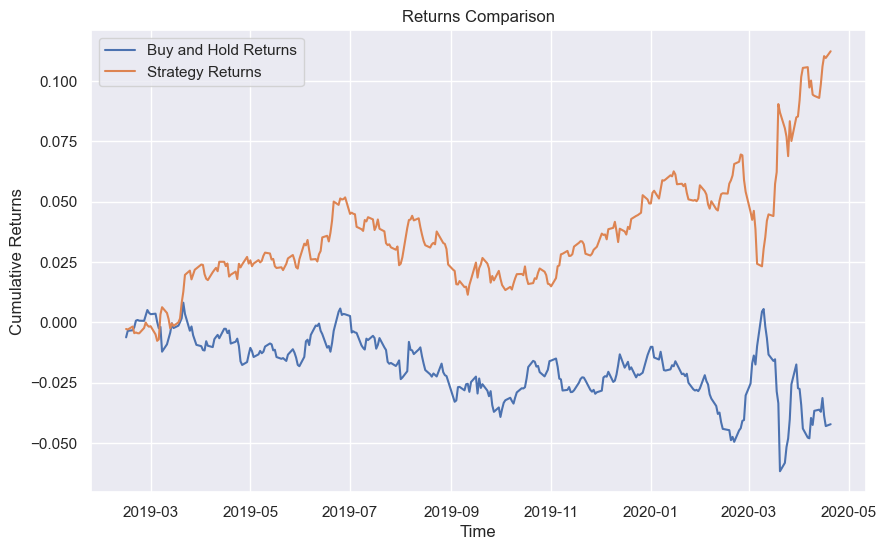

,Open,High,Low,Close,Adj Close,Volume,returns,std_5,std_10,std_15,...,upper_band,middle_band,lower_band,macd,macdsignal,macdhist,sar,target,predicted,strategy_returns
Date,,,,,,,,,,,,,,,,,,,,,
2019-02-14,1.126405,1.130825,1.125062,1.126494,1.126494,0,-0.006170,0.003396,0.006916,0.006950,...,1.136909,1.130833,1.124758,-0.003854,-0.002584,-0.001270,1.147230,1,-1,-0.002696
2019-02-15,1.129471,1.129816,1.123495,1.129535,1.129535,0,0.002696,0.002949,0.006553,0.007093,...,1.135240,1.129965,1.124689,-0.003980,-0.002864,-0.001117,1.145456,1,-1,-0.000237
2019-02-18,1.129484,1.133414,1.129484,1.129803,1.129803,0,0.000237,0.002616,0.005572,0.007343,...,1.134121,1.129440,1.124760,-0.004012,-0.003093,-0.000919,1.143260,1,1,0.001232
2019-02-19,1.131209,1.134185,1.127701,1.131196,1.131196,0,0.001232,0.002546,0.004294,0.007329,...,1.134654,1.130099,1.125543,-0.003880,-0.003251,-0.000630,1.141283,1,-1,-0.002741
2019-02-20,1.134301,1.136958,1.132593,1.134301,1.134301,0,0.002741,0.002834,0.003144,0.007087,...,1.135335,1.130266,1.125196,-0.003485,-0.003298,-0.000188,1.139505,1,1,0.000295
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-04-14,1.091953,1.098394,1.091572,1.092299,1.092299,0,-0.000885,0.002890,0.006930,0.009959,...,1.096007,1.090838,1.085668,-0.003208,-0.003486,0.000278,1.082478,1,1,0.005696
2020-04-15,1.098237,1.098901,1.085765,1.098539,1.098539,0,0.005696,0.004321,0.006161,0.009447,...,1.100372,1.092642,1.084913,-0.002411,-0.003271,0.000859,1.083730,-1,-1,0.007335
2020-04-16,1.090382,1.090774,1.082966,1.090510,1.090510,0,-0.007335,0.003017,0.005820,0.009398,...,1.098867,1.093471,1.088075,-0.002401,-0.003097,0.000696,1.113784,-1,-1,0.004285


In [33]:
# Read backtest data
backtest_data = pd.read_csv('MLT03_data_EURUSD_backtest.csv', index_col=0, parse_dates=True)

# Backtest the strategy
bnh_returns, s_returns, data = backtest(backtest_data, model)

data

In [34]:
print('Buy and Hold Returns:', bnh_returns)
print('Strategy Returns:', s_returns)

Buy and Hold Returns: -0.044937002315672055
Strategy Returns: 0.11230564546393211
